In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_and_convert_images(folder_path, band3_name='BAND3.tif', band4_name='BAND4.tif'):
    img1 = cv2.imread(os.path.join(folder_path, band3_name), cv2.IMREAD_UNCHANGED)
    img2 = cv2.imread(os.path.join(folder_path, band4_name), cv2.IMREAD_UNCHANGED)

    if img1 is None or img2 is None:
        raise ValueError("Could not read one or both band images")

    img1_8bit = cv2.normalize(img1, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    img2_8bit = cv2.normalize(img2, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    return img1_8bit, img2_8bit


folder_path = r"C:\Users\proha\OneDrive\Desktop\computer vision\RAF30JAN2026047471009900060SSANSTUC00GTDB"

band3, band4 = read_and_convert_images(folder_path)

print("Band3 shape:", band3.shape)

Band3 shape: (16330, 18274)


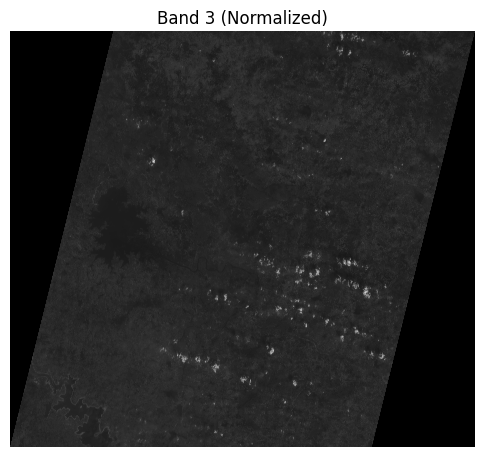

In [3]:
plt.figure(figsize=(6,6))
plt.imshow(band3, cmap='gray')
plt.title("Band 3 (Normalized)")
plt.axis("off")
plt.show()

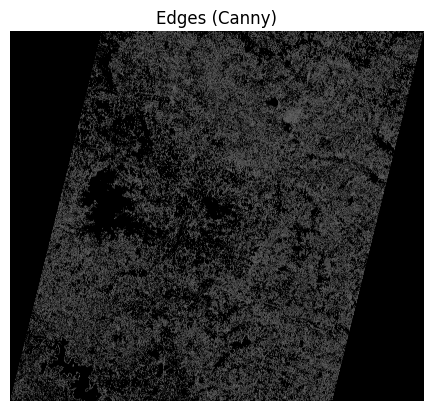

In [4]:
edges = cv2.Canny(band3, 5, 30)

plt.figure()
plt.imshow(edges, cmap='gray')
plt.title("Edges (Canny)")
plt.axis("off")
plt.show()

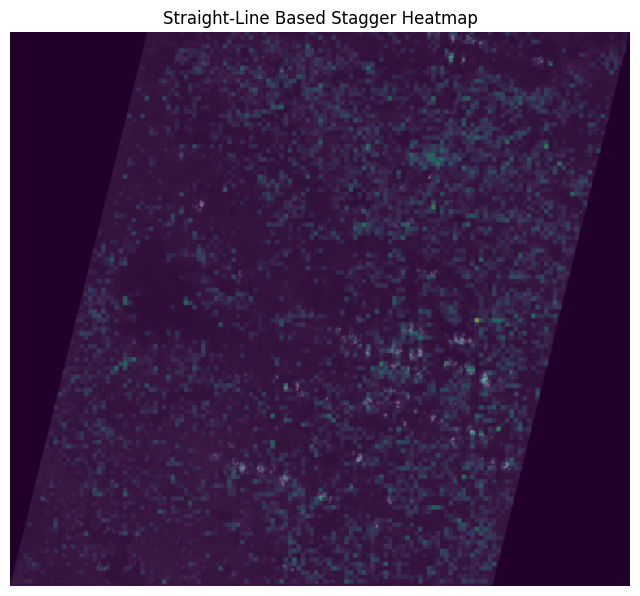

In [5]:
# ==========================================
# Straight-Line Based Stagger Heatmap
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

band3_small = cv2.resize(band3, None, fx=0.5, fy=0.5)

patch_size = 64
stride = 64

H, W = band3_small.shape

heatmap = np.zeros((H, W))
count_map = np.zeros((H, W))

def patch_line_score(patch):

    edges = cv2.Canny(patch, 10, 50)

    lines = cv2.HoughLinesP(
        edges,
        1,
        np.pi/180,
        threshold=20,
        minLineLength=25,   # important
        maxLineGap=5
    )

    if lines is None:
        return 0

    score = 0

    for line in lines:
        x1, y1, x2, y2 = line[0]

        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)

        angle = abs(np.degrees(np.arctan2(y2-y1, x2-x1)))

        # near-horizontal straight lines only
        if angle < 15 or angle > 165:
            score += length

    return score


for i in range(0, H - patch_size + 1, stride):
    for j in range(0, W - patch_size + 1, stride):

        patch = band3_small[i:i+patch_size, j:j+patch_size]

        score = patch_line_score(patch)

        heatmap[i:i+patch_size, j:j+patch_size] += score
        count_map[i:i+patch_size, j:j+patch_size] += 1


count_map[count_map == 0] = 1
heatmap = heatmap / count_map

heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

plt.figure(figsize=(8,8))
plt.imshow(band3_small, cmap='gray')
plt.imshow(heatmap_norm, alpha=0.5)
plt.title("Straight-Line Based Stagger Heatmap")
plt.axis("off")
plt.show()

In [6]:
# ==========================================
# Create Heatmap Patches
# ==========================================

heatmap_patches = []

patch_size = 64
stride = 64

H, W = heatmap_norm.shape

for i in range(0, H - patch_size + 1, stride):
    for j in range(0, W - patch_size + 1, stride):

        patch = heatmap_norm[i:i+patch_size, j:j+patch_size]

        heatmap_patches.append(((i, j), patch))

print("Total heatmap patches:", len(heatmap_patches))

Total heatmap patches: 18034


In [18]:
def extract_patches_with_heatmap(
    image,
    heatmap,
    patch_size=64,
    stride=64
):

    patches = []

    h, w = image.shape

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):

            patch = image[
                i:i+patch_size,
                j:j+patch_size
            ]

            heat_patch = heatmap[
                i:i+patch_size,
                j:j+patch_size
            ]

            patches.append(
                (
                    (i, j),
                    patch,
                    heat_patch
                )
            )

    return patches

In [ ]:
# ==========================================================
# CORRECT FINAL SHARP PATCH VIEWER
# (Uses matching sizes: band3_small + heatmap_norm)
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# ----------------------------------------------------------
# 1. Create patches (MATCHED SHAPES)
# ----------------------------------------------------------

def extract_patches_with_heatmap(image, heatmap, patch_size=128, stride=128):

    patches = []
    h, w = image.shape

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):

            patch = image[i:i+patch_size, j:j+patch_size]
            heat_patch = heatmap[i:i+patch_size, j:j+patch_size]

            if patch.size == 0 or heat_patch.size == 0:
                continue

            score = np.mean(heat_patch)

            patches.append(((i, j), patch, score))

    return patches


# Use MATCHING arrays
patches_with_scores = extract_patches_with_heatmap(
    band3_small,
    heatmap_norm,
    patch_size=128,
    stride=128
)

print("Total patches:", len(patches_with_scores))


# ----------------------------------------------------------
# 2. Viewer
# ----------------------------------------------------------

def show_patch(idx):

    (i, j), raw_patch, score = patches_with_scores[idx]

    patch_size = raw_patch.shape[0]

    heat_patch = heatmap_norm[i:i+patch_size, j:j+patch_size].copy()

    if heat_patch.size == 0:
        print("Empty heat patch")
        return

    # Smooth heatmap
    heat_patch = cv2.GaussianBlur(heat_patch, (5,5), 0)

    # Remove weak heat
    heat_patch[heat_patch < 0.18] = 0

    # Sharpen image
    kernel = np.array([
        [0,-1,0],
        [-1,5,-1],
        [0,-1,0]
    ])

    sharp_patch = cv2.filter2D(raw_patch, -1, kernel)

    plt.figure(figsize=(12,5))

    # -----------------------------
    # Left: Sharp patch
    # -----------------------------
    plt.subplot(1,2,1)

    plt.imshow(
        sharp_patch,
        cmap='gray',
        interpolation='nearest'
    )

    plt.title(f"Sharp Patch {idx}\nLocation ({i},{j})")
    plt.axis("off")

    # -----------------------------
    # Right: Heatmap overlay
    # -----------------------------
    plt.subplot(1,2,2)

    plt.imshow(
        sharp_patch,
        cmap='gray',
        interpolation='nearest'
    )

    plt.imshow(
        heat_patch,
        cmap='hot',
        alpha=0.55,
        interpolation='nearest'
    )

    plt.title(f"Likely Stagger Zones\nScore = {score:.3f}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


widgets.interact(
    show_patch,
    idx=widgets.IntSlider(
        min=0,
        max=len(patches_with_scores)-1,
        step=1,
        value=0,
        description='Patch:',
        continuous_update=False
    )
)

Total patches: 4473


interactive(children=(IntSlider(value=0, continuous_update=False, description='Patch:', max=4472), Output()), …

<function __main__.show_patch(idx)>

In [9]:
print("band3_small shape:", band3_small.shape)
print("heatmap_norm shape:", heatmap_norm.shape)

band3_small shape: (8165, 9137)
heatmap_norm shape: (8165, 9137)


In [10]:
def patch_hough_score_fast(patch):

    edges = cv2.Canny(patch, 10, 50)

    lines = cv2.HoughLinesP(
        edges,
        1,
        np.pi/180,
        threshold=15,
        minLineLength=25,
        maxLineGap=4
    )

    if lines is None:
        return 0

    score = 0

    for line in lines:
        x1, y1, x2, y2 = line[0]

        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)

        angle = abs(np.degrees(np.arctan2(y2-y1, x2-x1)))

        if angle < 45 or angle > 135:
            score += length

    return score

In [11]:
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)

angles = []

if lines is not None:
    for rho, theta in lines[:,0]:
        angle_deg = theta * 180 / np.pi
        angles.append(angle_deg)

angles = np.array(angles)

print("Detected lines:", len(angles))

Detected lines: 392855


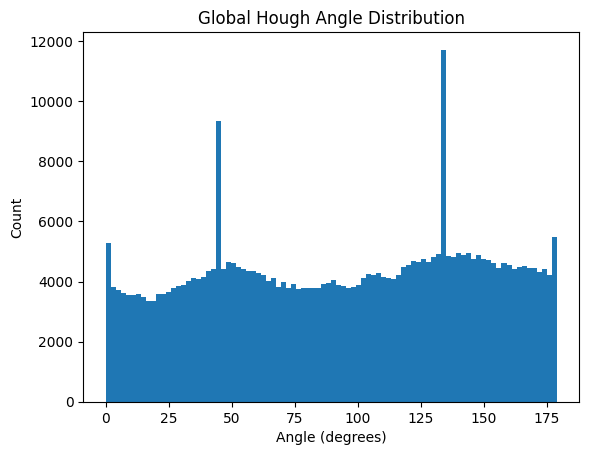

In [12]:
plt.figure()
plt.hist(angles, bins=90)
plt.title("Global Hough Angle Distribution")
plt.xlabel("Angle (degrees)")
plt.ylabel("Count")
plt.show()

In [13]:
def extract_patches(image, patch_size=(64,64), stride=32):
    patches = []
    h, w = image.shape

    for i in range(0, h - patch_size[0] + 1, stride):
        for j in range(0, w - patch_size[1] + 1, stride):
            patch = image[i:i+patch_size[0], j:j+patch_size[1]]
            patches.append(((i, j), patch))

    return patches


band3_patches = extract_patches(band3)

print("Total patches:", len(band3_patches))

Total patches: 290130


In [14]:
def patch_hough_score(patch):
    edges = cv2.Canny(patch, 50, 150)
    lines = cv2.HoughLines(edges, 1, np.pi/180, 50)

    if lines is None:
        return 0

    angles = []
    for rho, theta in lines[:,0]:
        angle_deg = theta * 180 / np.pi
        angles.append(angle_deg)

    angles = np.array(angles)

    # horizontal dominance
    horizontal_strength = np.sum((angles < 10) | (angles > 170))

    return horizontal_strength

In [15]:
stagger_scores = []

for (i, j), patch in band3_patches:
    score = patch_hough_score(patch)
    stagger_scores.append(score)

stagger_scores = np.array(stagger_scores)

print("Max score:", stagger_scores.max())


Max score: 0


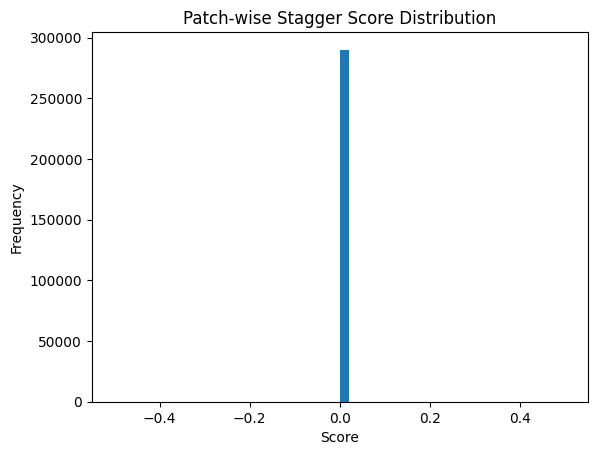

In [16]:
plt.figure()
plt.hist(stagger_scores, bins=50)
plt.title("Patch-wise Stagger Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

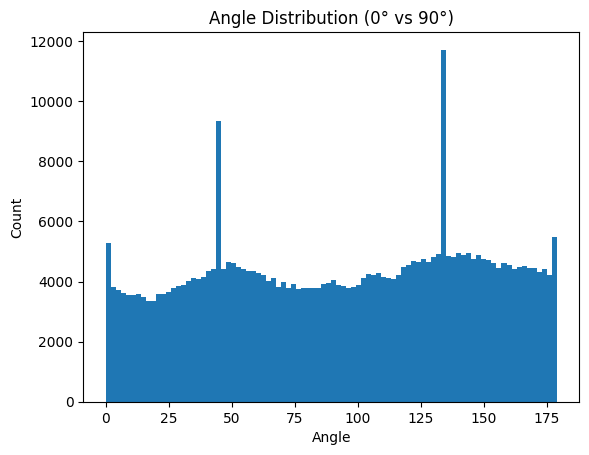

In [17]:
plt.figure()
plt.hist(angles, bins=90)
plt.title("Angle Distribution (0° vs 90°)")
plt.xlabel("Angle")
plt.ylabel("Count")
plt.show()